![Dr. Semmelweis](ignaz_semmelweis_1860.jpeg)

Hungarian physician Dr. Ignaz Semmelweis worked at the Vienna General Hospital with childbed fever patients. Childbed fever is a deadly disease affecting women who have just given birth, and in the early 1840s, as many as 10% of the women giving birth died from it at the Vienna General Hospital. Dr.Semmelweis discovered that it was the contaminated hands of the doctors delivering the babies, and on June 1st, 1847, he decreed that everyone should wash their hands, an unorthodox and controversial request; nobody in Vienna knew about bacteria.

You will reanalyze the data that made Semmelweis discover the importance of handwashing and its impact on the hospital.

The data is stored as two CSV files within the `data` folder.

`yearly_deaths_by_clinic.csv` contains the number of women giving birth at the two clinics at the Vienna General Hospital between the years 1841 and 1846.

| Column | Description |
|--------|-------------|
|`year`  |Years (1841-1846)|
|`births`|Number of births|
|`deaths`|Number of deaths|
|`clinic`|Clinic 1 or clinic 2|

`monthly_deaths.csv` contains data from 'Clinic 1' of the hospital where most deaths occurred.

| Column | Description |
|--------|-------------|
|`date`|Date (YYYY-MM-DD)
|`births`|Number of births|
|`deaths`|Number of deaths|

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 98 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (2): births, deaths
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 12 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): clinic
dbl (3): year, births, deaths

ℹ 

Rows: 98
Columns: 3
$ date   <date> 1841-01-01, 1841-02-01, 1841-03-01, 1841-04-01, 1841-05-01, 18…
$ births <dbl> 254, 239, 277, 255, 255, 200, 190, 222, 213, 236, 235, 307, 311…
$ deaths <dbl> 37, 18, 12, 4, 2, 10, 16, 3, 4, 26, 53, 64, 38, 27, 26, 10, 18,…
Rows: 12
Columns: 4
$ year   <dbl> 1841, 1842, 1843, 1844, 1845, 1846, 1841, 1842, 1843, 1844, 184…
$ births <dbl> 3036, 3287, 3060, 3157, 3492, 4010, 2442, 2659, 2739, 2956, 324…
$ deaths <dbl> 237, 518, 274, 260, 241, 459, 86, 202, 164, 68, 66, 105
$ clinic <chr> "clinic 1", "clinic 1", "clinic 1", "clinic 1", "clinic 1", "cl…


year,births,deaths,clinic,proportion
<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1841,3036,237,clinic 1,0.07806324
1842,3287,518,clinic 1,0.15759051
1843,3060,274,clinic 1,0.08954248
1844,3157,260,clinic 1,0.08235667
1845,3492,241,clinic 1,0.06901489
1846,4010,459,clinic 1,0.11446384


date,births,deaths,proportion
<date>,<dbl>,<dbl>,<dbl>
1841-01-01,254,37,0.145669291
1841-02-01,239,18,0.075313808
1841-03-01,277,12,0.043321300
1841-04-01,255,4,0.015686275
1841-05-01,255,2,0.007843137
1841-06-01,200,10,0.050000000


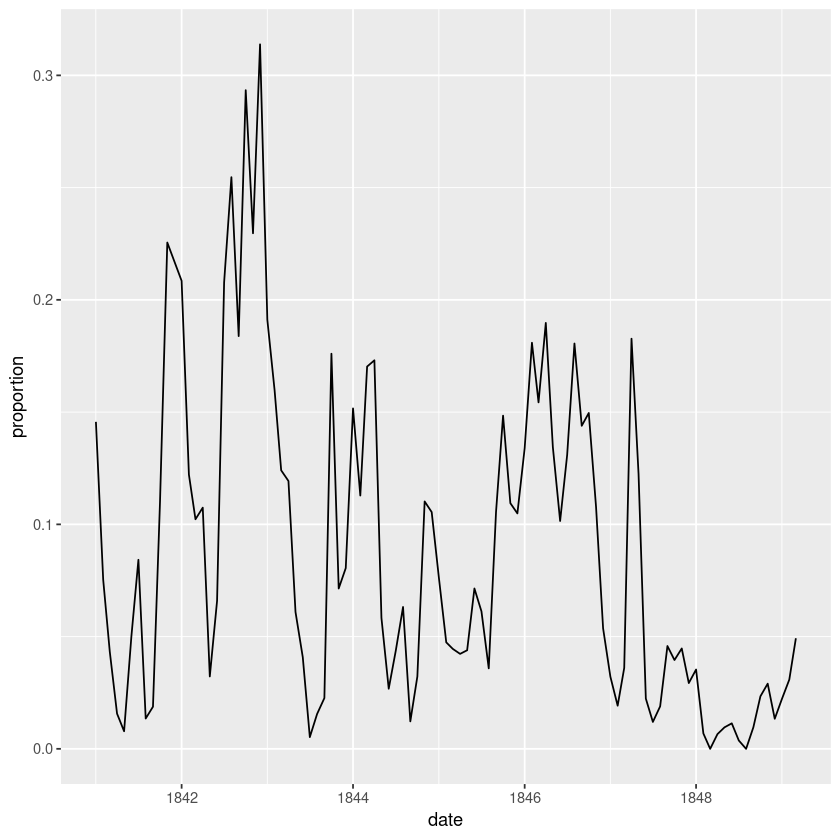

date,births,deaths,proportion,handwashing_start,handwashing_started
<date>,<dbl>,<dbl>,<dbl>,<date>,<lgl>
1841-01-01,254,37,0.145669291,1847-06-01,FALSE
1841-02-01,239,18,0.075313808,1847-06-01,FALSE
1841-03-01,277,12,0.043321300,1847-06-01,FALSE
1841-04-01,255,4,0.015686275,1847-06-01,FALSE
1841-05-01,255,2,0.007843137,1847-06-01,FALSE
1841-06-01,200,10,0.050000000,1847-06-01,FALSE


date,births,deaths,proportion,handwashing_start,handwashing_started
<date>,<dbl>,<dbl>,<dbl>,<date>,<lgl>
1848-10-01,299,7,0.02341137,1847-06-01,TRUE
1848-11-01,310,9,0.02903226,1847-06-01,TRUE
1848-12-01,373,5,0.01340483,1847-06-01,TRUE
1849-01-01,403,9,0.02233251,1847-06-01,TRUE
1849-02-01,389,12,0.03084833,1847-06-01,TRUE
1849-03-01,406,20,0.04926108,1847-06-01,TRUE


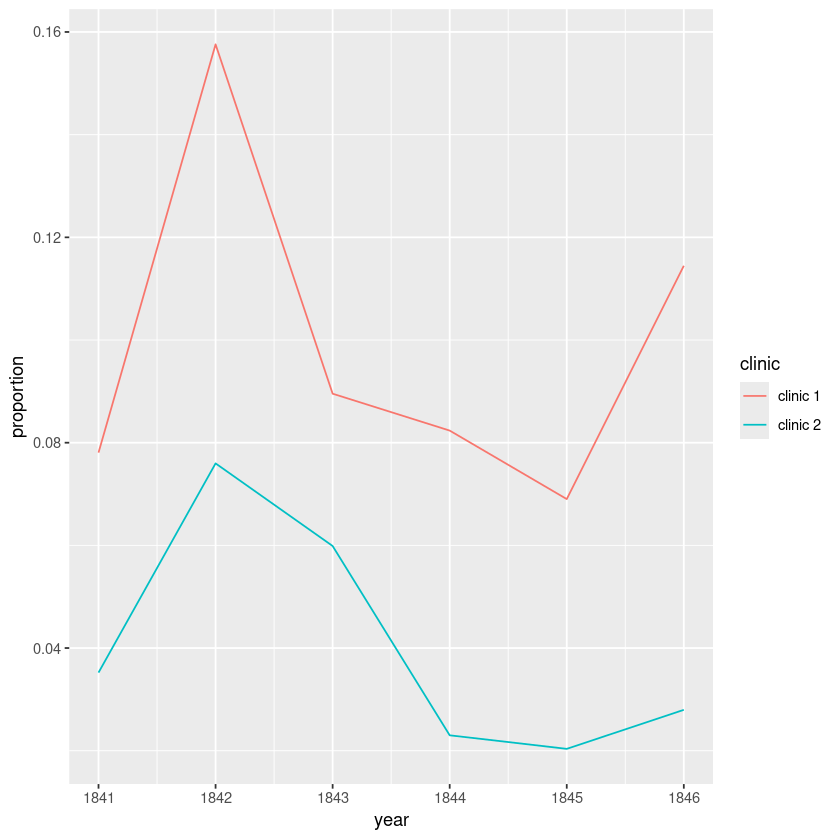

handwashing_started,mean_proportion
<lgl>,<dbl>
FALSE,0.10504998
TRUE,0.02109338


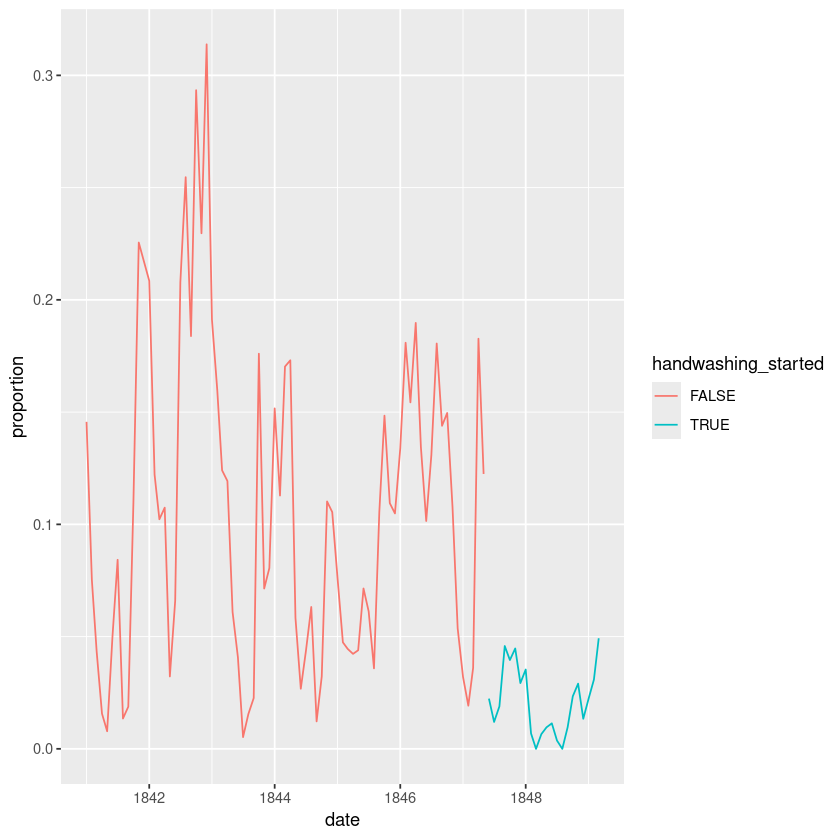

In [1]:
# Imported libraries
library(tidyverse)

# Start coding here..
#start with uploading csv
monthly_start <-read_csv('data/monthly_deaths.csv')
yearly_start <-read_csv('data/yearly_deaths_by_clinic.csv')
#inspect the csvs
glimpse(monthly_start)
glimpse(yearly_start)
#add the death proportion to each dataframe
monthly_proportion <-monthly_start%>%
mutate(proportion=deaths/births)

yearly <- yearly_start %>%
mutate(proportion=deaths/births)


# check proportions are correct
head(yearly)
head(monthly_proportion)

# plot both the df 
 ggplot(monthly_proportion, aes(x=date, y=proportion))+
geom_line()

ggplot(yearly, aes(x=year, y=proportion, color=clinic))+
geom_line()

#add handwashing started
monthly_temp <-monthly_proportion %>%
mutate(handwashing_start = as.Date('1847-06-01'))%>%
mutate(handwashing_started= date >= handwashing_start)

# investigate the handwashing_started column is correct
 head(monthly_temp)
tail(monthly_temp)

#remove hand_washing start column
monthly <- monthly_temp %>%
select(date, births, deaths, proportion, handwashing_started)
# plot new df
ggplot(monthly, aes(x=date, y=proportion, color= handwashing_started))+
geom_line()

#create the monthly_summary df
monthly_summary <- monthly %>%
group_by(handwashing_started)%>%
summarize(mean_proportion= mean(proportion)) 
head(monthly_summary)

